In [1]:
# Import libraries

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load preprocessed dataset

df = pd.read_csv("../data/preprocessed_support_tickets.csv")

print("Preprocessed dataset loaded successfully!")

Preprocessed dataset loaded successfully!


In [3]:
# Check dataset

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Rows: 47837
Columns: ['Document', 'Topic_group', 'text_length', 'cleaned_text', 'cleaned_text_length']


In [4]:
# Select text and category

X_text = df["cleaned_text"]
y = df["Topic_group"]

print("Number of categories:", y.nunique())
print("\nCategories:")
print(y.value_counts())

Number of categories: 8

Categories:
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


In [5]:
# Split data into training and testing sets

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 38269
Testing samples: 9568


In [6]:
# Create TF-IDF vectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

In [7]:
# Convert text into TF-IDF features

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Training TF-IDF shape:", X_train.shape)
print("Testing TF-IDF shape:", X_test.shape)

Training TF-IDF shape: (38269, 10000)
Testing TF-IDF shape: (9568, 10000)


In [8]:
# Train Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=2000
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [9]:
# Predict ticket categories

logistic_predictions = logistic_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [10]:
# Evaluate Logistic Regression model

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Accuracy:", logistic_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

Logistic Regression Accuracy: 0.8544105351170569

Classification Report:
                       precision    recall  f1-score   support

               Access       0.91      0.88      0.90      1425
Administrative rights       0.89      0.64      0.75       352
           HR Support       0.87      0.87      0.87      2183
             Hardware       0.79      0.89      0.84      2724
     Internal Project       0.91      0.80      0.85       424
        Miscellaneous       0.83      0.82      0.82      1412
             Purchase       0.98      0.85      0.91       493
              Storage       0.94      0.81      0.87       555

             accuracy                           0.85      9568
            macro avg       0.89      0.82      0.85      9568
         weighted avg       0.86      0.85      0.85      9568



In [11]:
# Train Naive Bayes model

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [12]:
# Predict ticket categories using Naive Bayes

nb_predictions = nb_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [13]:
# Evaluate Naive Bayes model

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print("Naive Bayes Accuracy:", nb_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        nb_predictions
    )
)

Naive Bayes Accuracy: 0.7786371237458194

Classification Report:
                       precision    recall  f1-score   support

               Access       0.86      0.78      0.82      1425
Administrative rights       0.94      0.26      0.41       352
           HR Support       0.84      0.77      0.81      2183
             Hardware       0.67      0.91      0.77      2724
     Internal Project       0.94      0.60      0.73       424
        Miscellaneous       0.76      0.73      0.75      1412
             Purchase       0.97      0.83      0.89       493
              Storage       0.94      0.67      0.78       555

             accuracy                           0.78      9568
            macro avg       0.86      0.70      0.75      9568
         weighted avg       0.80      0.78      0.77      9568



In [14]:
# Train Linear SVM model

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

print("Linear SVM model trained successfully!")

Linear SVM model trained successfully!


In [15]:
# Predict ticket categories using Linear SVM

svm_predictions = svm_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [16]:
# Evaluate Linear SVM model

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print("Linear SVM Accuracy:", svm_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svm_predictions
    )
)

Linear SVM Accuracy: 0.8569188963210702

Classification Report:
                       precision    recall  f1-score   support

               Access       0.90      0.89      0.90      1425
Administrative rights       0.86      0.72      0.78       352
           HR Support       0.86      0.86      0.86      2183
             Hardware       0.82      0.86      0.84      2724
     Internal Project       0.88      0.85      0.86       424
        Miscellaneous       0.82      0.82      0.82      1412
             Purchase       0.96      0.88      0.92       493
              Storage       0.92      0.86      0.89       555

             accuracy                           0.86      9568
            macro avg       0.88      0.84      0.86      9568
         weighted avg       0.86      0.86      0.86      9568



In [17]:
# Compare all classification models

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        logistic_accuracy,
        nb_accuracy,
        svm_accuracy
    ]
})

model_results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,Linear SVM,0.856919
0,Logistic Regression,0.854411
1,Naive Bayes,0.778637


In [18]:
# Create predictions using the best model

best_model = svm_model
best_predictions = svm_predictions

print("Best model: Linear SVM")
print("Accuracy:", accuracy_score(y_test, best_predictions))

Best model: Linear SVM
Accuracy: 0.8569188963210702


In [19]:
# Create confusion matrix

cm = confusion_matrix(
    y_test,
    best_predictions
)

print(cm)

[[1274    4   33   69    5   32    3    5]
 [   8  253   11   69    1    8    0    2]
 [  30    4 1888  160   20   68    3   10]
 [  70   25  136 2351   12  107   12   11]
 [   2    0   25   22  360   15    0    0]
 [  27    3   78  119   11 1161    2   11]
 [   4    5    8   31    1    8  434    2]
 [   3    1   24   38    0   11    0  478]]


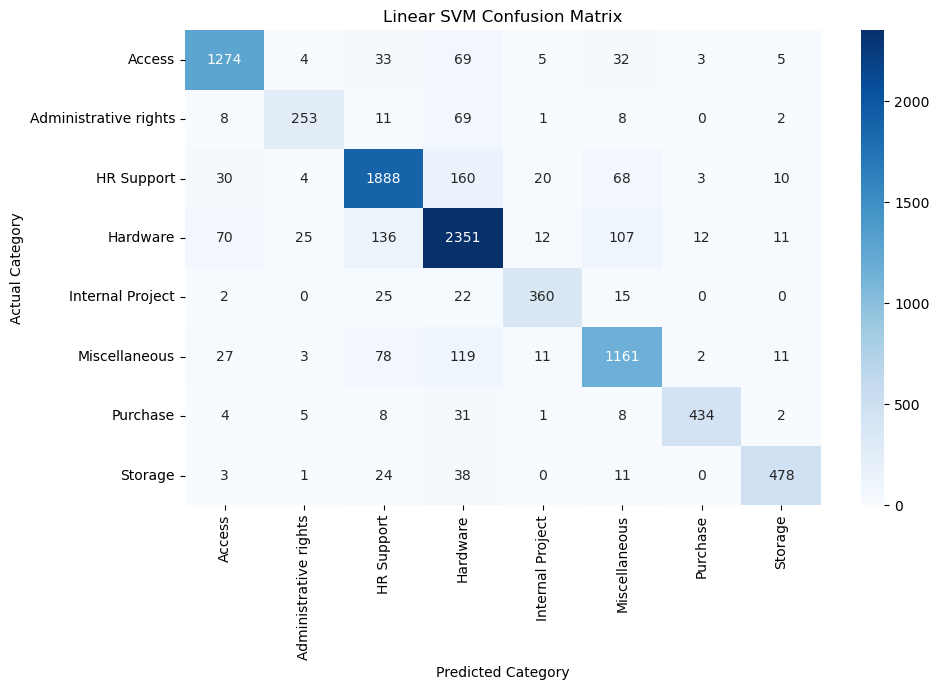

In [20]:
# Plot confusion matrix

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.tight_layout()
plt.show()

In [21]:
# Display final classification report

print(
    classification_report(
        y_test,
        best_predictions
    )
)

                       precision    recall  f1-score   support

               Access       0.90      0.89      0.90      1425
Administrative rights       0.86      0.72      0.78       352
           HR Support       0.86      0.86      0.86      2183
             Hardware       0.82      0.86      0.84      2724
     Internal Project       0.88      0.85      0.86       424
        Miscellaneous       0.82      0.82      0.82      1412
             Purchase       0.96      0.88      0.92       493
              Storage       0.92      0.86      0.89       555

             accuracy                           0.86      9568
            macro avg       0.88      0.84      0.86      9568
         weighted avg       0.86      0.86      0.86      9568



In [22]:
# Save the best model

joblib.dump(
    best_model,
    "../models/linear_svm_ticket_classifier.pkl"
)

print("Linear SVM model saved successfully!")

Linear SVM model saved successfully!


In [23]:
# Save the TF-IDF vectorizer

joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

print("TF-IDF vectorizer saved successfully!")

TF-IDF vectorizer saved successfully!


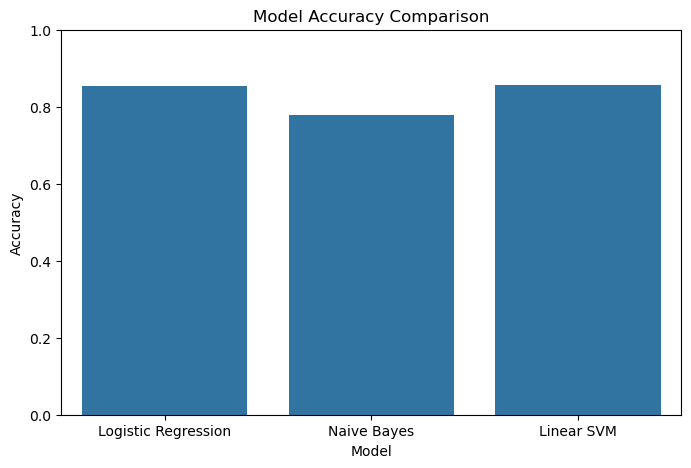

In [24]:
# Plot model accuracy comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

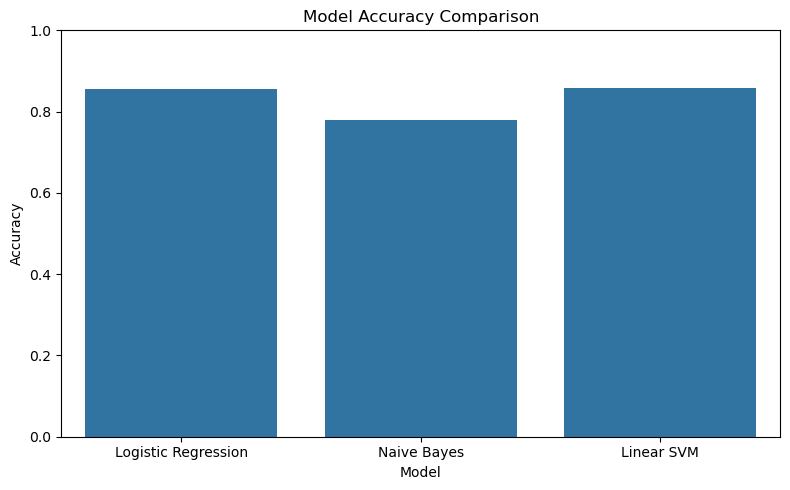

Model accuracy graph saved successfully!


In [25]:
# Save model accuracy comparison graph

import os

plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.tight_layout()

# Create graphs folder if it does not exist
os.makedirs("../outputs/graphs", exist_ok=True)

# Save graph
plt.savefig(
    "../outputs/graphs/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Model accuracy graph saved successfully!")

In [26]:
# Save model comparison results

model_results.to_csv(
    "../outputs/model_results/category_model_comparison.csv",
    index=False
)

print("Model comparison results saved successfully!")

Model comparison results saved successfully!


In [27]:
# Save confusion matrix

cm_df = pd.DataFrame(
    cm,
    index=best_model.classes_,
    columns=best_model.classes_
)

cm_df.to_csv(
    "../outputs/confusion_matrix/linear_svm_confusion_matrix.csv"
)

print("Confusion matrix saved successfully!")

Confusion matrix saved successfully!


In [28]:
# Create .gitignore file

gitignore_content = """# Python cache
__pycache__/
*.pyc

# Jupyter checkpoints
.ipynb_checkpoints/

# Virtual environments
venv/
env/

# IDE files
.vscode/
.idea/

# OS files
.DS_Store
Thumbs.db
"""

with open("../.gitignore", "w") as file:
    file.write(gitignore_content)

print(".gitignore created successfully!")

.gitignore created successfully!


In [29]:
# Check .gitignore location

import os

print("Current folder:")
print(os.getcwd())

print("\n.gitignore exists:")
print(os.path.exists("../.gitignore"))

Current folder:
C:\Users\SRI GOPI KRISHNA\Downloads\Support_Ticket_Classification\notebooks

.gitignore exists:
True


In [30]:
# Check important file sizes

import os

files = [
    "../data/all_tickets_processed_improved_v3.csv",
    "../data/cleaned_support_tickets.csv",
    "../data/preprocessed_support_tickets.csv",
    "../data/final_support_tickets.csv",
    "../models/linear_svm_ticket_classifier.pkl",
    "../models/tfidf_vectorizer.pkl"
]

for file in files:
    size_mb = os.path.getsize(file) / (1024 * 1024)
    print(f"{file}: {size_mb:.2f} MB")

../data/all_tickets_processed_improved_v3.csv: 13.89 MB
../data/cleaned_support_tickets.csv: 14.07 MB
../data/preprocessed_support_tickets.csv: 26.37 MB
../data/final_support_tickets.csv: 26.59 MB
../models/linear_svm_ticket_classifier.pkl: 0.61 MB
../models/tfidf_vectorizer.pkl: 0.35 MB
